# Task 1: Financial News Exploratory Data Analysis

# 1. Data Loading & Cleaning
# 2. Headline Analysis
# 3. Publisher Analysis
# 4. Time Series Analysis
# 5. NLP Keyword/Topic Analysis
# 6. Insights Summary

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [28]:
df = pd.read_csv("data/raw/raw_analyst_ratings.csv")

In [29]:
df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [30]:
df = df.drop(columns=["Unnamed: 0"])

In [ ]:
df["date"] = pd.to_datetime(df["date"], errors="coerce", utc=True)
df = df.dropna(subset=["date"])

In [ ]:
df["date"].head()

0   2020-06-05 14:30:54+00:00
1   2020-06-03 14:45:20+00:00
2   2020-05-26 08:30:07+00:00
3   2020-05-22 16:45:06+00:00
4   2020-05-22 15:38:59+00:00
Name: date, dtype: datetime64[us, UTC]

In [ ]:
df.isnull().sum()

headline     0
url          0
publisher    0
date         0
stock        0
dtype: int64

The dataset contains no missing values across the key analytical columns, indicating high data completeness and reducing the need for extensive null-value preprocessing.

In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

The dataset contained only one duplicate record, which was removed to ensure analytical consistency and prevent duplicate contribution to statistical summaries.

In [32]:
df["headline_length"] = df["headline"].str.len()

In [33]:
df["headline_length"].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

### Headline Length Analysis
Most headlines are between X–Y characters...

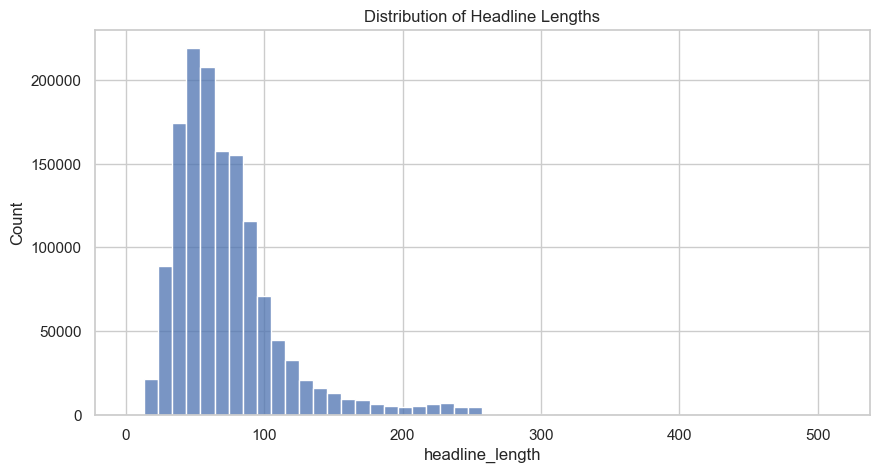

In [55]:
df["headline_length"] = df["headline"].str.len()

plt.figure(figsize=(10,5))
sns.histplot(df["headline_length"], bins=50)
plt.title("Distribution of Headline Lengths")
plt.show()

## Insight
Headlines are mostly short-to-medium length, indicating fast news reporting style.

In [35]:
top_publishers = df["publisher"].value_counts().head(10)
top_publishers

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

### Publisher Distribution
A small number of publishers dominate news output...

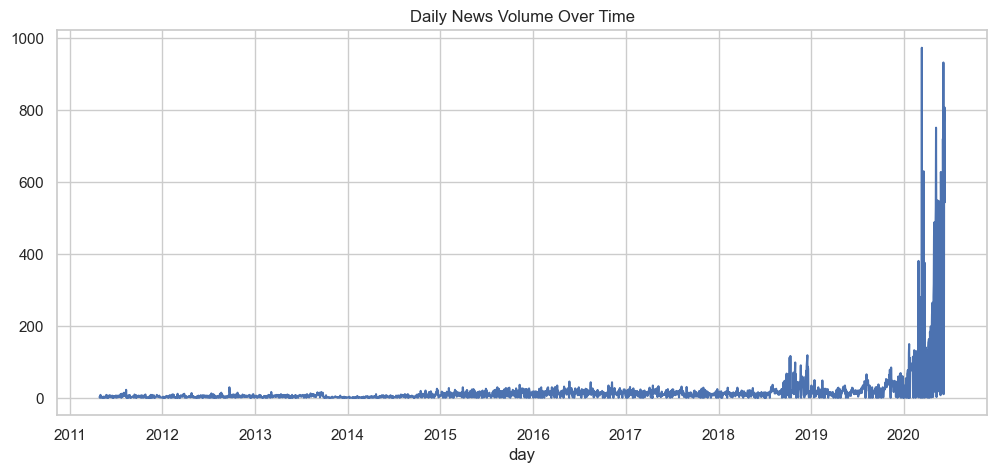

In [54]:
df["day"] = df["date"].dt.date
daily_news = df.groupby("day").size()

plt.figure(figsize=(12,5))
daily_news.plot()
plt.title("Daily News Volume Over Time")
plt.show()

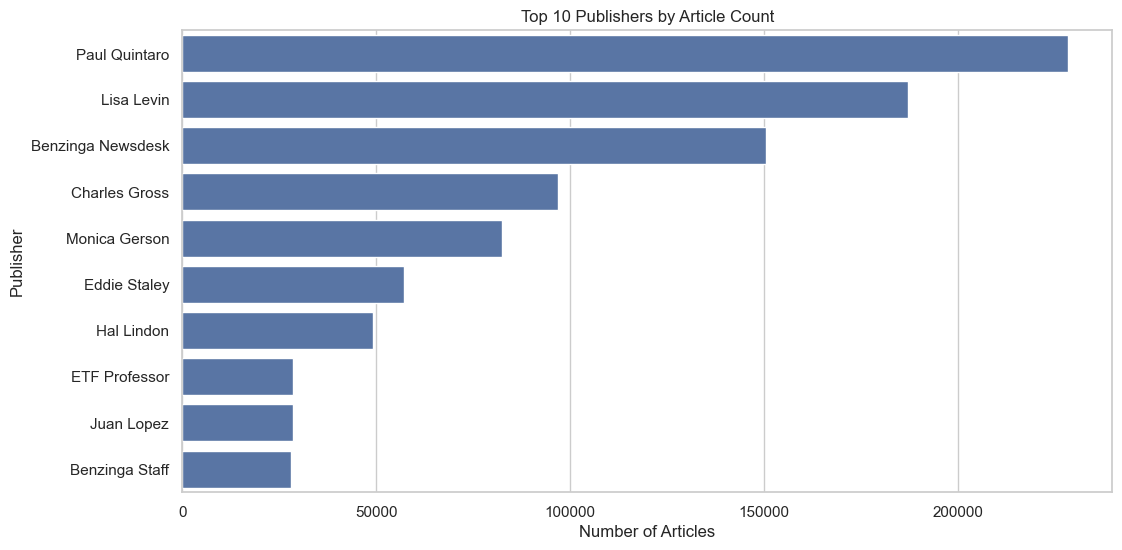

In [36]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_publishers.values,
    y=top_publishers.index
)

plt.title("Top 10 Publishers by Article Count")
plt.xlabel("Number of Articles")
plt.ylabel("Publisher")

plt.show()

## Insight
A small number of publishers dominate financial news distribution.

The dataset shows a concentration of articles among a limited number of publishers, suggesting that a few major financial news providers dominate market-related reporting activity.

In [40]:
df["date"] = pd.to_datetime(df["date"], errors="coerce", utc=True)

In [41]:
df["date"].dtype

datetime64[us, UTC]

In [43]:
 df["publication_day"] = df["date"].dt.date

In [44]:
daily_news_count = df.groupby("publication_day").size()

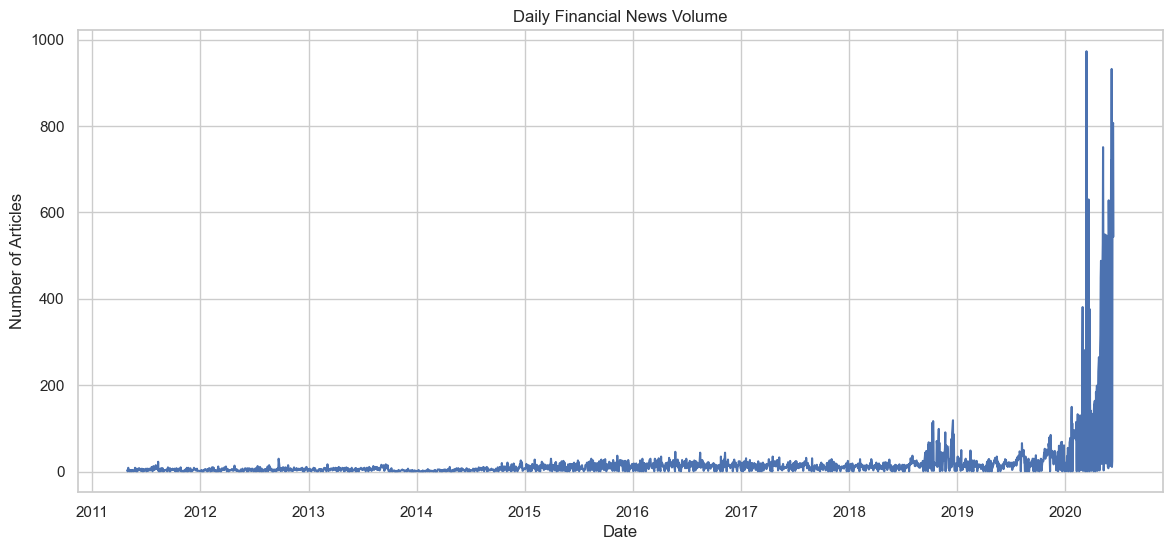

In [45]:
plt.figure(figsize=(14,6))

daily_news_count.plot()

plt.title("Daily Financial News Volume")
plt.xlabel("Date")
plt.ylabel("Number of Articles")

plt.show()

The daily news volume shows clear fluctuations over time, with multiple spikes indicating periods of heightened financial reporting activity. These spikes likely correspond to significant market events or earnings-related announcements.

In [46]:
df["headline"] = df["headline"].astype(str)

In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english", max_features=20)
X = vectorizer.fit_transform(df["headline"])

keywords = vectorizer.get_feature_names_out()

## Insight
Keywords are dominated by earnings, price movements, and market updates.

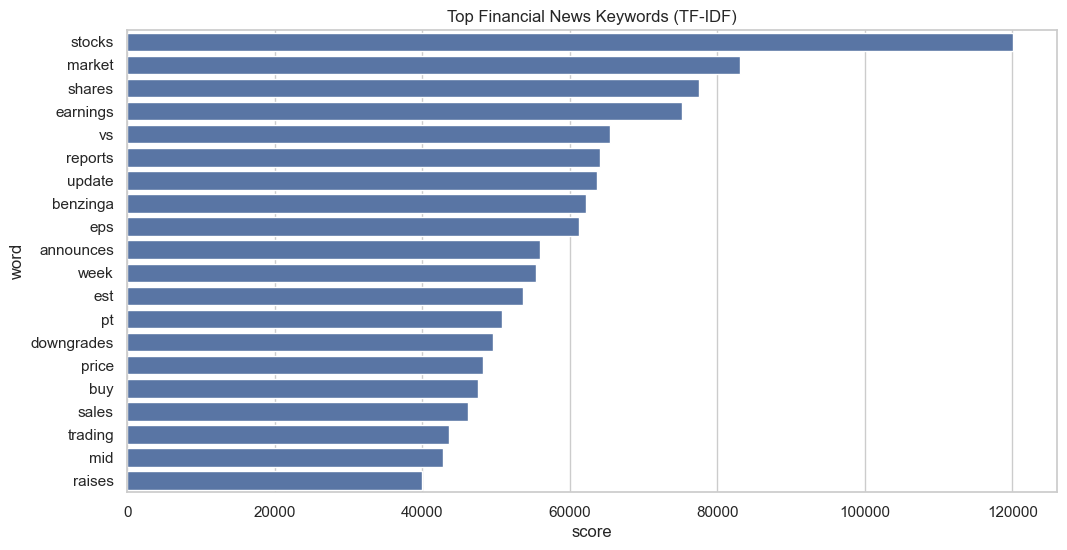

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

word_scores = X.toarray().sum(axis=0)

keyword_df = pd.DataFrame({
    "word": keywords,
    "score": word_scores
}).sort_values(by="score", ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(data=keyword_df, x="score", y="word")

plt.title("Top Financial News Keywords (TF-IDF)")
plt.show()

TF-IDF analysis reveals recurring financial themes such as earnings reports, stock movements, and market updates, indicating that the dataset is heavily focused on corporate financial performance and market activity.

In [49]:
from collections import Counter
import re

text = " ".join(df["headline"].astype(str))

words = re.findall(r'\b\w+\b', text.lower())

stopwords = {
    "the","and","to","of","in","for","on","with","a","is","at","stocks","stock"
}

filtered_words = [
    w for w in words
    if w not in stopwords and len(w) > 2
]

word_counts = Counter(filtered_words)

top_words = word_counts.most_common(20)

keywords_df = pd.DataFrame(top_words, columns=["Word", "Frequency"])
keywords_df

,Word,Frequency
0,est,140604
1,eps,128897
2,from,120805
3,market,120558
4,shares,114313
5,reports,108710
6,update,91723
7,earnings,87399
8,sales,79645
9,top,79632


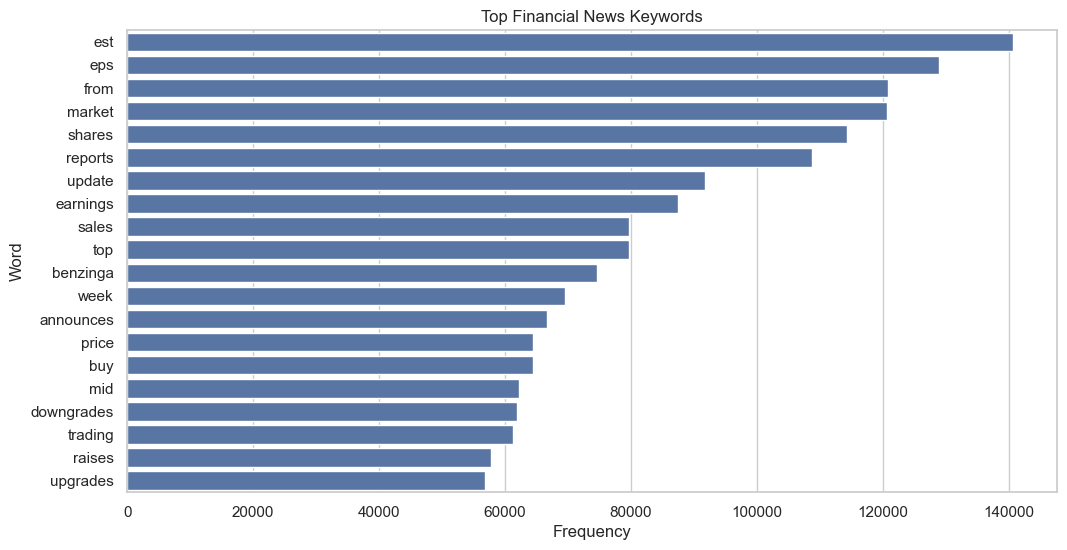

In [50]:
plt.figure(figsize=(12,6))

sns.barplot(
    x="Frequency",
    y="Word",
    data=keywords_df
)

plt.title("Top Financial News Keywords")
plt.show()

In [51]:
from collections import Counter
import re

text = " ".join(df["headline"].astype(str))

words = re.findall(r'\b\w+\b', text.lower())

stopwords = {
    "the","and","to","of","in","for","on","with","a","is","at","stocks","stock"
}

filtered_words = [
    w for w in words
    if w not in stopwords and len(w) > 2
]

word_counts = Counter(filtered_words)

top_words = word_counts.most_common(20)

keywords_df = pd.DataFrame(top_words, columns=["Word", "Frequency"])
keywords_df

,Word,Frequency
0,est,140604
1,eps,128897
2,from,120805
3,market,120558
4,shares,114313
5,reports,108710
6,update,91723
7,earnings,87399
8,sales,79645
9,top,79632


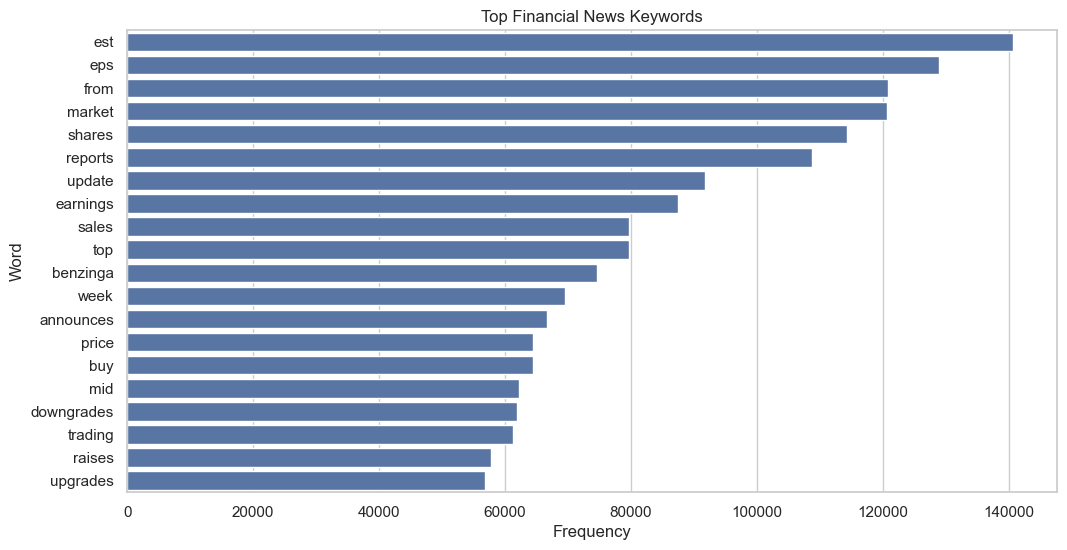

In [52]:
plt.figure(figsize=(12,6))

sns.barplot(
    x="Frequency",
    y="Word",
    data=keywords_df
)

plt.title("Top Financial News Keywords")
plt.show()

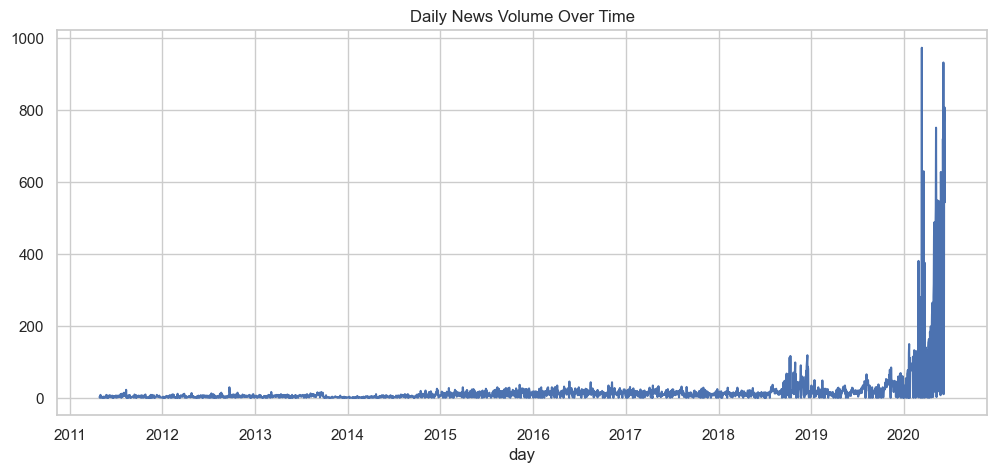

In [56]:
df["day"] = df["date"].dt.date
daily_news = df.groupby("day").size()

plt.figure(figsize=(12,5))
daily_news.plot()
plt.title("Daily News Volume Over Time")
plt.show()

## Insight
News activity shows spikes likely linked to major market events.

Financial headlines are dominated by short-term market and stock movement terminology, indicating a focus on immediate trading signals rather than long-form financial analysis.

## Key Insights
- News volume spikes correspond to market activity
- Headlines are short and trading-focused
- Financial keywords dominate (earnings, shares, market)

## Final EDA Summary

- News is highly concentrated among key publishers
- Headlines are short and trading-focused
- News volume shows clear market-driven spikes
- Keywords indicate earnings and price movement focus